# Plot log2 fold change vs DMSO per patient
Plots of the per-patient log2 fold changes from `0.calculate_log2_fold_change`.
1. Viability (% of DMSO) heatmap (patient x treatment).
2. Morphology mean absolute log2 fold change heatmap (patient x treatment, per compartment).
3. Morphology vs viability log2 fold change scatter (one point per patient x treatment).
4. Mean viability log2 fold change vs mean morphology log2 fold change per treatment (averaged over patients).

In [1]:
list_of_packages <- c("ggplot2", "dplyr", "tidyr", "arrow", "RColorBrewer", "ggrepel")
for (package in list_of_packages) {
    suppressPackageStartupMessages(
        suppressWarnings(
            library(package, character.only = TRUE, quietly = TRUE, warn.conflicts = FALSE)
        )
    )
}

find_git_root <- function() {
    cwd <- getwd()
    if (dir.exists(file.path(cwd, ".git"))) {
        return(cwd)
    }
    current_path <- cwd
    while (dirname(current_path) != current_path) {
        parent_path <- dirname(current_path)
        if (dir.exists(file.path(parent_path, ".git"))) {
            return(parent_path)
        }
        current_path <- parent_path
    }
    stop("No Git root directory found.")
}

root_dir <- find_git_root()
source(file.path(root_dir, "utils", "r_plot_themes.r"))
source(file.path(root_dir, "utils", "r_plot_funcs.r"))

In [2]:
results_dir <- file.path(root_dir, "5.differential_analysis", "results")
figures_dir <- file.path(root_dir, "5.differential_analysis", "figures")
dir.create(figures_dir, recursive = TRUE, showWarnings = FALSE)

summary_path <- file.path(results_dir, "log2fc_summary.parquet")
viability_path <- file.path(results_dir, "viability_log2fc.parquet")
viability_heatmap_path <- file.path(figures_dir, "viability_percent_heatmap.pdf")
morphology_heatmap_path <- file.path(figures_dir, "morphology_log2fc_heatmap.pdf")
combined_heatmap_path <- file.path(figures_dir, "viability_morphology_heatmaps.pdf")
morphology_vs_viability_path <- file.path(figures_dir, "morphology_vs_viability_log2fc.pdf")

# Viability is % of the patient's DMSO, so 100 means no change.
viability_midpoint <- 100
compartment_labels <- c(organoid = "Organoid", single_cell = "Single cell")
tumor_type_levels <- c("cNF", "pNF", "MPNST", "Other")

In [3]:
summary_df <- read_parquet(summary_path) %>%
    mutate(
        treatment_label = paste0(
            Metadata_Experiment_Treatment, " ",
            as.character(Metadata_Experiment_Dose), " ",
            Metadata_Experiment_Unit
        ),
        Metadata_Biology_TumorType = factor(Metadata_Biology_TumorType, levels = tumor_type_levels),
        is_mek = treatment_moa_map[Metadata_Experiment_Treatment] == "MEK1/2 inhibitor"
    )

treatment_label_levels <- summary_df %>%
    distinct(Metadata_Experiment_Treatment, Metadata_Experiment_Dose, treatment_label) %>%
    arrange(match(Metadata_Experiment_Treatment, custom_treatment_order), Metadata_Experiment_Dose) %>%
    pull(treatment_label)
summary_df$treatment_label <- factor(summary_df$treatment_label, levels = treatment_label_levels)

morphology_df <- summary_df %>%
    pivot_longer(
        cols = ends_with("_mean_abs_log2fc"),
        names_to = "compartment",
        names_pattern = "(.*)_mean_abs_log2fc",
        values_to = "mean_abs_log2fc"
    ) %>%
    filter(!is.na(mean_abs_log2fc)) %>%
    mutate(compartment = factor(compartment_labels[compartment], levels = compartment_labels))
head(summary_df)

Metadata_Biology_PatientTumor,Metadata_Biology_TumorType,Metadata_Experiment_Treatment,Metadata_Experiment_Dose,Metadata_Experiment_Unit,organoid_mean_abs_log2fc,single_cell_mean_abs_log2fc,viability_log2fc,treatment_label,is_mek
<chr>,<fct>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<fct>,<lgl>
NF0014_T1,cNF,Binimetinib,1,uM,0.3662379,0.4327987,-0.06270615,Binimetinib 1 uM,TRUE
NF0014_T1,cNF,Binimetinib,10,uM,0.3783624,0.6284641,-0.19848609,Binimetinib 10 uM,TRUE
NF0014_T1,cNF,Cabozantinib,1,uM,0.3130133,0.3425665,0.24856014,Cabozantinib 1 uM,FALSE
NF0014_T1,cNF,Copanlisib,1,uM,0.2223269,0.4517958,-1.15059849,Copanlisib 1 uM,FALSE
NF0014_T1,cNF,Digoxin,1,uM,0.4223251,0.7602813,-2.15205974,Digoxin 1 uM,FALSE
NF0014_T1,cNF,Everolimus,1,uM,0.2896988,0.2217974,-0.32392776,Everolimus 1 uM,FALSE


In [4]:
# Fill in patient x treatment combinations that were not tested so they plot as NA.
viability_heatmap_df <- summary_df %>%
    inner_join(
        read_parquet(viability_path) %>%
            select(
                Metadata_Biology_PatientTumor,
                Metadata_Experiment_Treatment,
                Metadata_Experiment_Dose,
                Metadata_Experiment_Unit,
                Metadata_Viability_Percentage
            ),
        by = c(
            "Metadata_Biology_PatientTumor",
            "Metadata_Experiment_Treatment",
            "Metadata_Experiment_Dose",
            "Metadata_Experiment_Unit"
        )
    ) %>%
    complete(nesting(Metadata_Biology_PatientTumor, Metadata_Biology_TumorType), treatment_label)
morphology_heatmap_df <- morphology_df %>%
    complete(
        compartment,
        nesting(Metadata_Biology_PatientTumor, Metadata_Biology_TumorType),
        treatment_label
    )

## Single-cell morphology heatmap
Mean absolute log2 fold change across features: how much the morphology moved away from DMSO, regardless of direction.
Grey tiles are treatments that were not on that patient's plate.

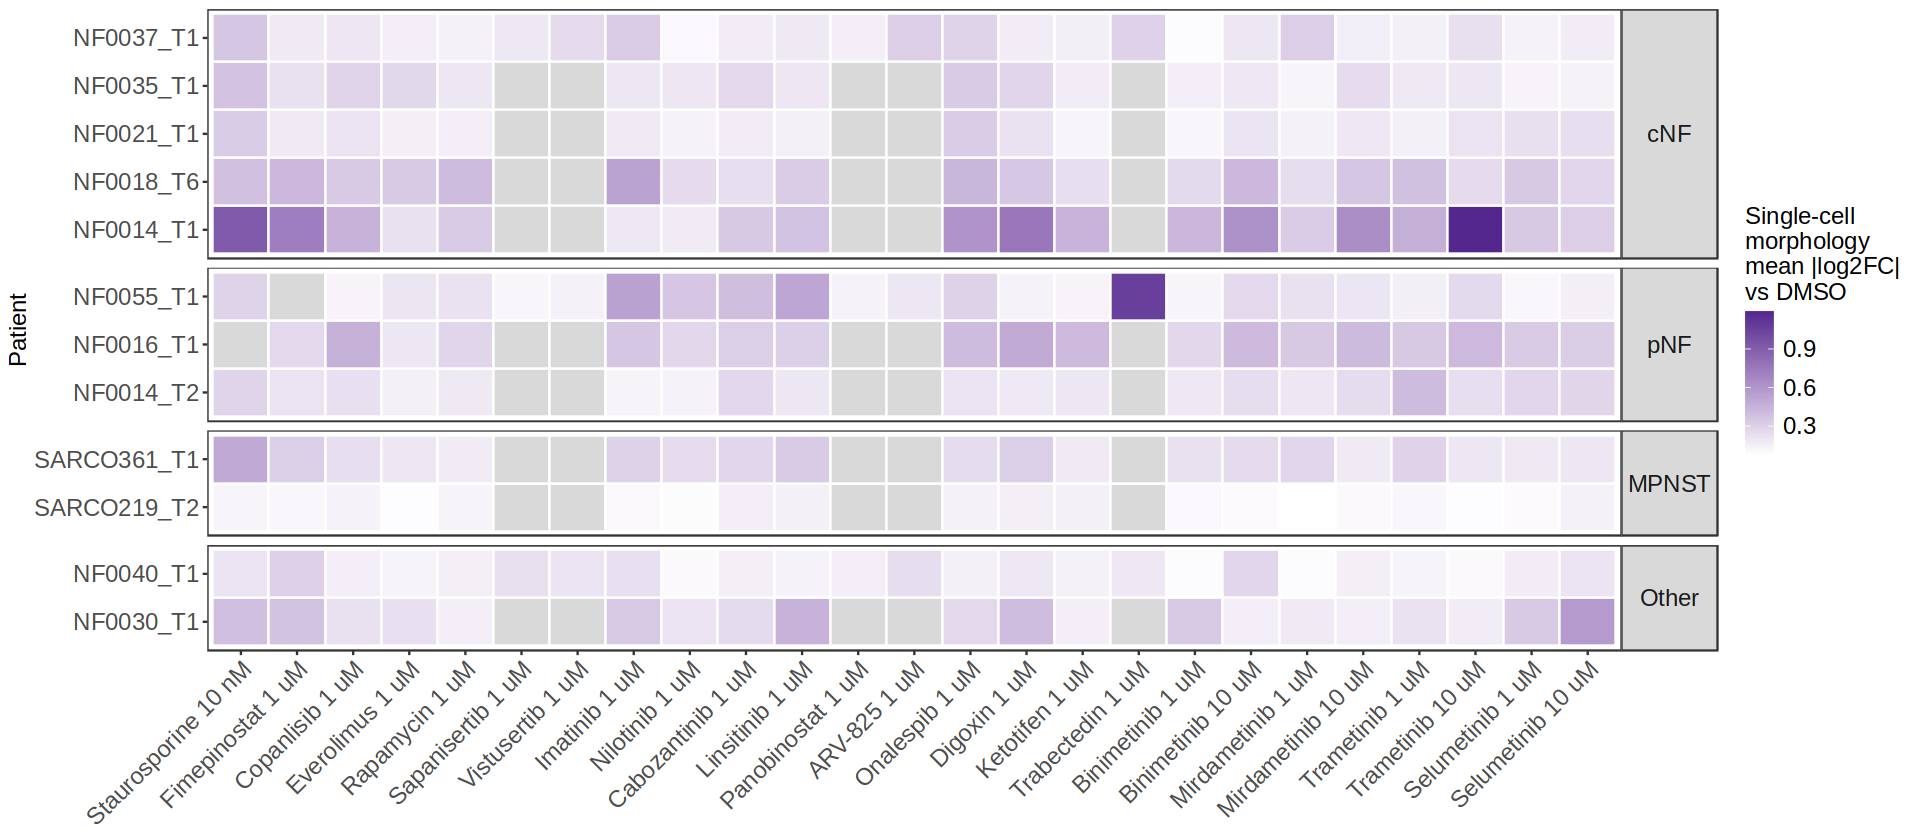

In [5]:
options(repr.plot.width = 16, repr.plot.height = 7)
morphology_heatmap <- (
    ggplot(
        morphology_heatmap_df %>% filter(compartment == "Single cell"),
        aes(x = treatment_label, y = Metadata_Biology_PatientTumor, fill = mean_abs_log2fc)
    )
    + geom_tile(color = "white", linewidth = 0.5)
    + scale_fill_gradient(low = "white", high = "#54278f", na.value = "grey85")
    + facet_grid(Metadata_Biology_TumorType ~ ., scales = "free_y", space = "free_y")
    + labs(
        x = NULL,
        y = "Patient",
        fill = "Single-cell\nmorphology\nmean |log2FC|\nvs DMSO"
    )
    + theme_manuscript(base_size = 14, x_text = "angled")
    + theme(panel.grid = element_blank(), strip.text.y = element_text(angle = 0))
)
morphology_heatmap
# save the plot as a pdf
invisible(save_plots_pdf(
    list(morphology_heatmap),
    file.path(root_dir, "5.differential_analysis", "figures", "morphology_heatmap.pdf"),
    width = 8,
    height = 4
))

## Morphology vs viability
One point per patient x treatment.

In [6]:
scatter_df <- morphology_df %>% filter(!is.na(viability_log2fc))

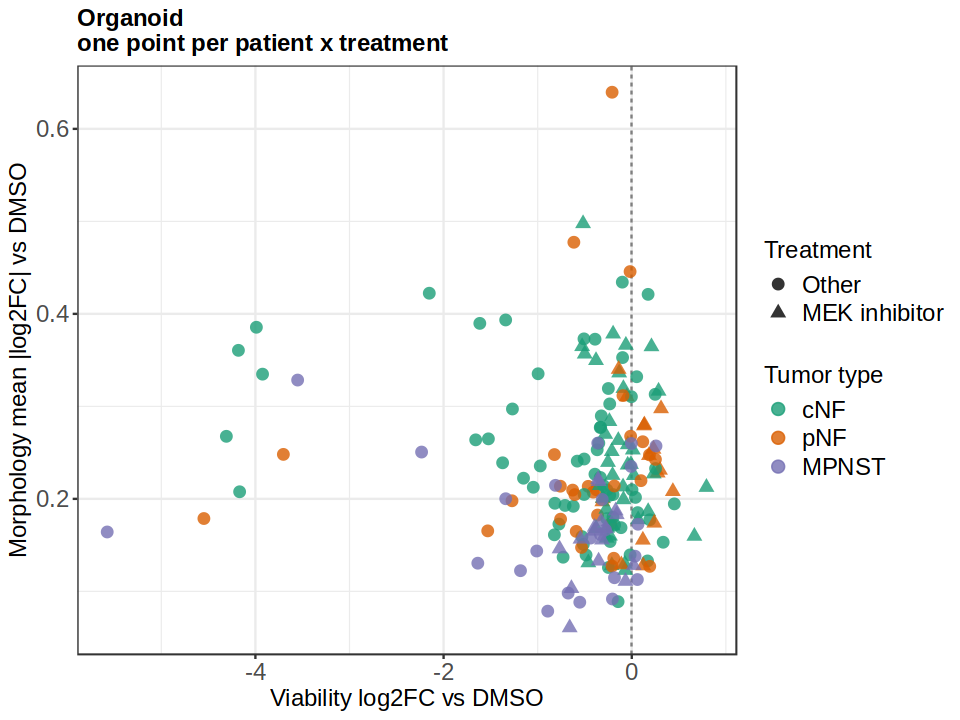

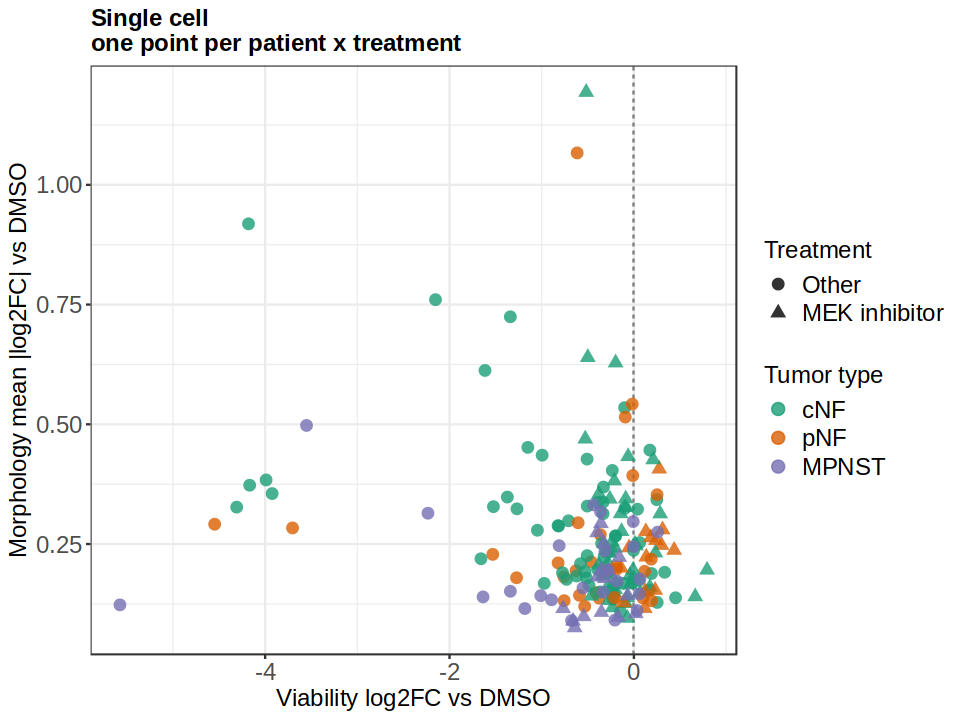

In [7]:
options(repr.plot.width = 8, repr.plot.height = 6)
scatter_plots <- lapply(levels(scatter_df$compartment), function(compartment_name) {
    (
        ggplot(
            scatter_df %>% filter(compartment == compartment_name),
            aes(x = viability_log2fc, y = mean_abs_log2fc, color = Metadata_Biology_TumorType, shape = is_mek)
        )
        + geom_vline(xintercept = 0, linetype = "dashed", color = "grey50")
        + geom_point(size = 3, alpha = 0.8)
        + scale_color_manual(values = tumor_type_palette)
        + scale_shape_manual(values = c("FALSE" = 16, "TRUE" = 17), labels = c("FALSE" = "Other", "TRUE" = "MEK inhibitor"))
        + labs(
            title = paste0(compartment_name, "\none point per patient x treatment"),
            x = "Viability log2FC vs DMSO",
            y = "Morphology mean |log2FC| vs DMSO",
            color = "Tumor type",
            shape = "Treatment"
        )
        + theme_manuscript(base_size = 14)
    )
})
for (scatter_plot in scatter_plots) print(scatter_plot)

## Mean viability vs mean morphology per treatment
Each point is one treatment within one tumor type, averaged over the patients of that tumor type that have both measurements: mean viability log2 fold change vs mean of the morphology mean |log2FC|.
Outlying treatments are picked from their mean over all tumor types (mean viability log2FC < -0.5, or the 3 largest morphology changes per compartment). Each outlying treatment is labelled once, on its tumor type point with the largest morphology change. Points are colored by tumor type and MEK inhibitors are triangles.

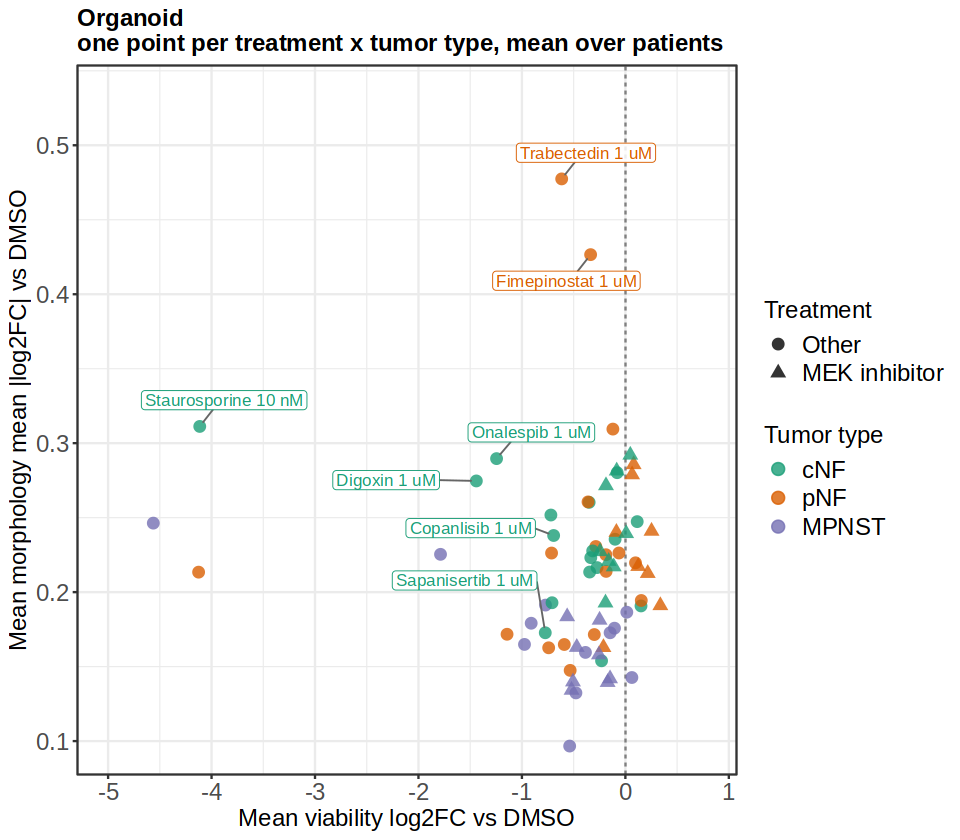

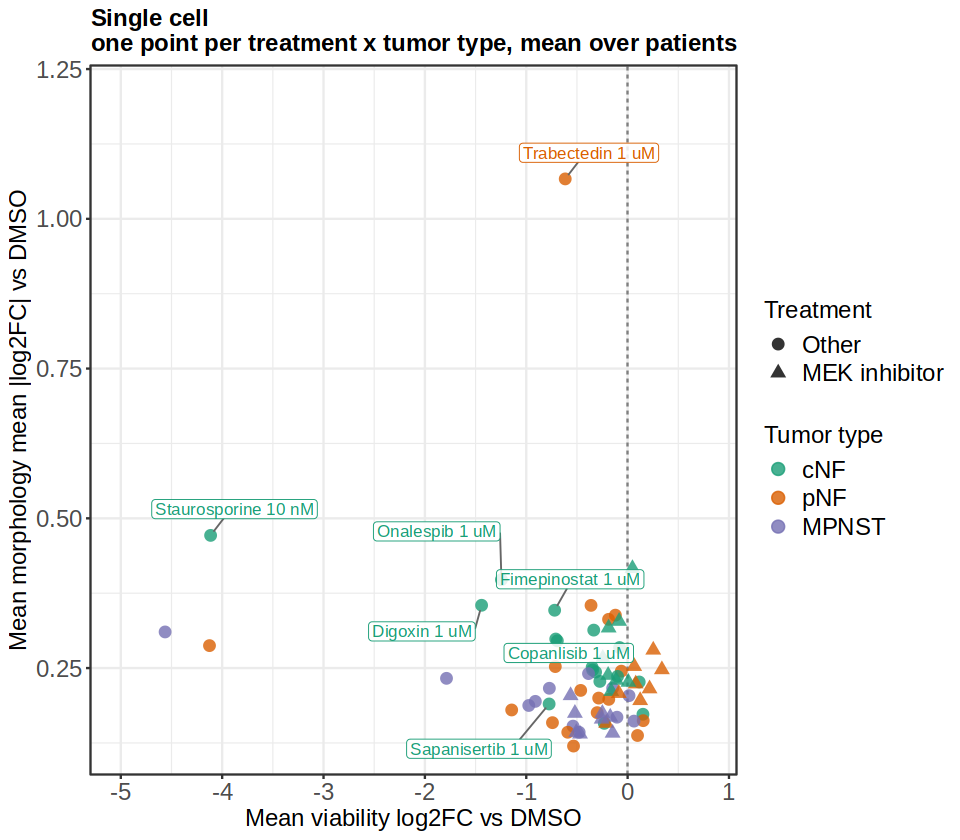

In [8]:
# Outlying treatments are picked from their mean over tumor types, so each is labelled once.
treatment_outlier_df <- scatter_df %>%
    group_by(compartment, treatment_label) %>%
    summarise(
        mean_viability_log2fc = mean(viability_log2fc),
        mean_morphology_log2fc = mean(mean_abs_log2fc),
        .groups = "drop"
    ) %>%
    group_by(compartment) %>%
    mutate(
        is_outlier = mean_viability_log2fc < -0.5 | rank(-mean_morphology_log2fc) <= 3
    ) %>%
    ungroup() %>%
    select(compartment, treatment_label, is_outlier)

treatment_mean_df <- scatter_df %>%
    group_by(compartment, treatment_label, is_mek, Metadata_Biology_TumorType) %>%
    summarise(
        mean_viability_log2fc = mean(viability_log2fc),
        mean_morphology_log2fc = mean(mean_abs_log2fc),
        n_patients = n(),
        .groups = "drop"
    ) %>%
    left_join(treatment_outlier_df, by = c("compartment", "treatment_label")) %>%
    group_by(compartment, treatment_label) %>%
    # Use "" (not NA) so ggrepel still treats unlabeled points as obstacles to avoid.
    mutate(
        label = if_else(
            is_outlier & row_number(-mean_morphology_log2fc) == 1,
            as.character(treatment_label),
            ""
        )
    ) %>%
    ungroup()

options(repr.plot.width = 8, repr.plot.height = 7)
treatment_mean_plots <- lapply(levels(treatment_mean_df$compartment), function(compartment_name) {
    (
        ggplot(
            treatment_mean_df %>% filter(compartment == compartment_name),
            aes(x = mean_viability_log2fc, y = mean_morphology_log2fc, color = Metadata_Biology_TumorType, shape = is_mek)
        )
        + geom_vline(xintercept = 0, linetype = "dashed", color = "grey50")
        + geom_point(size = 3, alpha = 0.8)
        + geom_label_repel(
            aes(label = label),
            size = 3.5,
            fill = alpha("white", 0.85),   # white box makes text readable over points/lines
            label.size = 0.2,              # thin border (use `linewidth` in ggrepel >= 0.9.4)
            label.padding = unit(0.15, "lines"),
            box.padding = 0.6,             # space around each label
            point.padding = 0.3,           # space between label and its point
            min.segment.length = 0,        # always draw a leader line
            segment.color = "grey40",
            segment.size = 0.4,
            force = 2,                     # push labels apart harder
            max.overlaps = Inf,            # never drop labels
            seed = 42,                     # reproducible placement
            show.legend = FALSE
        )
        + scale_x_continuous(expand = expansion(mult = 0.15))
        + scale_y_continuous(expand = expansion(mult = c(0.05, 0.2)))  # headroom for labels
        + scale_color_manual(values = tumor_type_palette)
        + scale_shape_manual(
            values = c("FALSE" = 16, "TRUE" = 17),
            labels = c("FALSE" = "Other", "TRUE" = "MEK inhibitor")
        )
        + coord_cartesian(clip = "off")
        + labs(
            title = paste0(compartment_name, "\none point per treatment x tumor type, mean over patients"),
            x = "Mean viability log2FC vs DMSO",
            y = "Mean morphology mean |log2FC| vs DMSO",
            color = "Tumor type",
            shape = "Treatment"
        )
        + theme_manuscript(base_size = 14)
    )
})
# Patient-level pages first, then treatment-level pages, in one PDF.
save_plots_pdf(
    c(scatter_plots, treatment_mean_plots),
    morphology_vs_viability_path,
    width = 8,
    height = c(6, 6, 7, 7)
)
for (treatment_mean_plot in treatment_mean_plots) print(treatment_mean_plot)